# July 2026: Comparison of EVACES Study with MSSP Study

In [1]:
# import numpy as np 
from mdof.utilities import Config
import os, pickle
from pathlib import Path
from mdof.prediction import Realization
from mdof.utilities.printing import plot_pred 
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science"])

## Select Event

In [2]:
origin_file_index = 1
event_id = origin_file_index + 1

## Select Study

The study determines the input and output channels to use for prediction.

In [3]:
STUDY = 'EVACES' # 'MSSP', 'EVACES'

METRIC = 'l2_norm'
stabilize = True

station_id = 'CE89324'
chan_conf = {
    'MSSP': {
        'inputs':  [3],
        'outputs': [7,9,4]
        },
    'EVACES': {
        'inputs':  [3,17,20],
        'outputs': [7,9,4]
        }
    }

## Load Events
Use the MSSP study as standard

In [4]:
with open("events.pkl","rb") as f:
    events = pickle.load(f)

## Train

In [5]:
realization = Realization(events[origin_file_index],
                          chan_conf[STUDY], 
                          Config(
                            m  = 500,
                            horizon = 190,
                            nc = 190,
                            order  = 8,
                            period_band = (0.1,0.6),
                            damping = 0.06,
                            pseudo = True,
                            outlook = 190,
                            threads = 8,
                            chunk = 200          
                          ),
                          stabilize=stabilize,
                          windowed_intensity=True,
                          verbose=True
)

peak acceleration (g): 0.0309698011043518
event date/time: 2016-12-08T14:50:00

        removing mode indices [0, 1, 6, 7] (real mode indices [0, 3])
        because magnitude of eigenvalue is greater than 1 ( np.abs(v) > 1)
        


## Test

In [6]:
METRIC_NAMES = {'are': "Absolute Relative Error",
                'l2_norm': r"Normalized $L_{2}$ Error",
                'sym': "Normalized Symmetric Error"}

Ch 7: Normalized $L_{2}$ Error = 0.31917191421249697
Ch 9: Normalized $L_{2}$ Error = 0.2547025341291271
Ch 4: Normalized $L_{2}$ Error = 0.3364769140012125


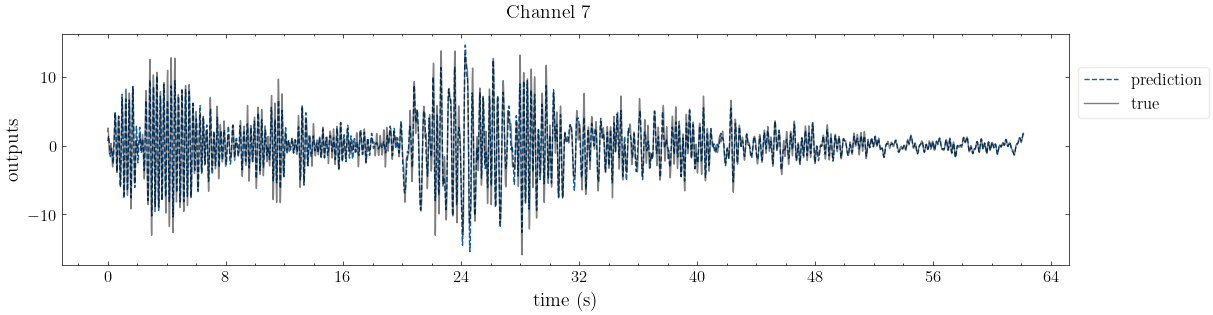

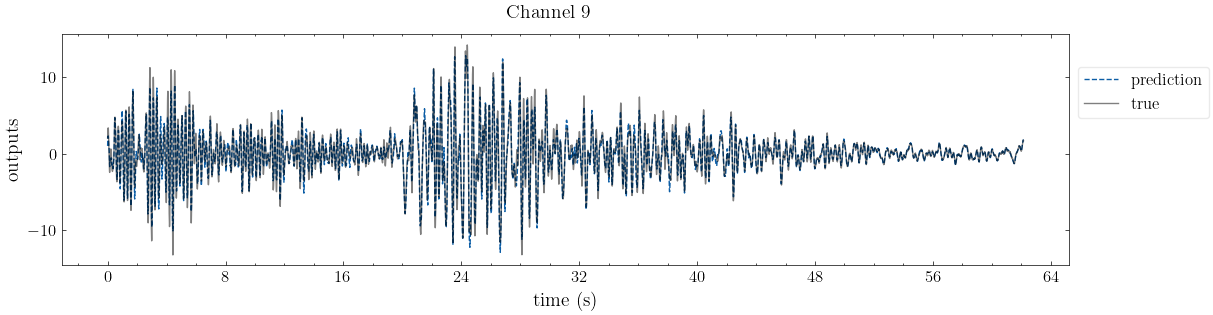

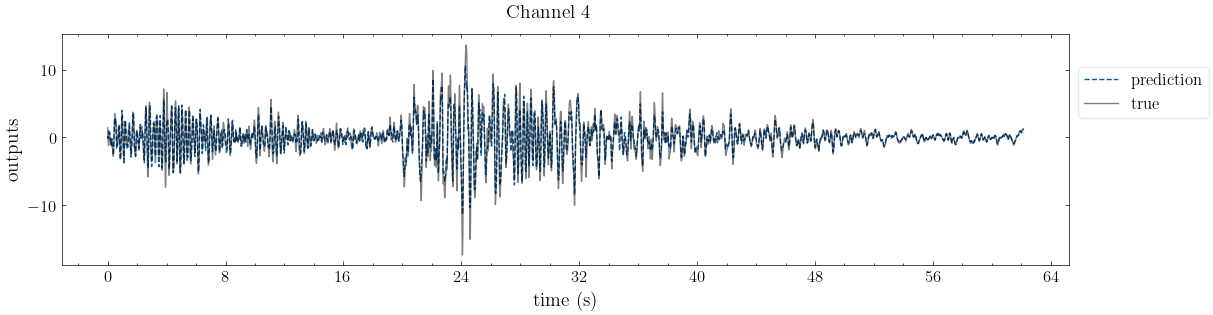

In [7]:
# Predict on the origin event and give detailed report
p = realization.predict(events[origin_file_index], align=False)
for i in p.channels():
    ch = chan_conf[STUDY]['outputs'][i]
    em = METRIC_NAMES[METRIC]
    print(f"Ch {ch}: {em} = {p.error(i, metric=METRIC)}")
    plot_pred(ytrue=p.true(i), models=p.test(i), t=p.time(i), title=f"Channel {ch}", figsize=(13,3))